# 모델을 불러와서 그림을 그리자

In [ ]:
import importlib
import json
import matplotlib.pyplot as plt
from modules import QGAN, Autoencoder  # 초기 import
import torch
from torch.autograd import Variable
import numpy as np
import pennylane as qml
from datetime import datetime

# args.txt 파일 경로 설정
base_dir = './runs/MNIST0123456789_35_ld16_InfoQGAN_Nov23_10_40_47'
args_file_path = f'{base_dir}/args.txt'

# args.txt 파일 읽기 및 파라미터 추출
with open(args_file_path, 'r') as file:
    args = json.load(file)

# 파라미터 설정
DIGITS = list(map(int, args["DIGITS"]))  # 학습할 숫자들 설정
DIGITS_STR = ''.join(map(str, DIGITS))
TARGETS = list(map(int, args["TARGETS"]))
TARGETS_STR = ''.join(map(str, TARGETS))
for target in TARGETS:
    assert target in DIGITS, f"Target {target} is not in DIGITS"

SEED_L = 2
SEED_R = 3
n_qubits = 5
output_qubits = 5
n_layers = 20
latent_dim = args["latent_dim"]
assert 2**output_qubits >= latent_dim, "Output qubits must support the latent dimension"

# 출력
print(f"DIGITS: {DIGITS}")
print(f"DIGITS_STR: {DIGITS_STR}")
print(f"TARGETS: {TARGETS}")
print(f"TARGETS_STR: {TARGETS_STR}")
print(f"n_qubits: {n_qubits}")
print(f"output_qubits: {output_qubits}")
print(f"n_layers: {n_layers}")
print(f"latent_dim: {latent_dim}")

# 생성자 초기화
dev = qml.device("lightning.qubit", wires=n_qubits)

generator_initial_params = Variable(
    torch.tensor(np.random.normal(-np.pi/3, np.pi/3, (n_layers, n_qubits, 1))), 
    requires_grad=True
)
generator = QGAN.QGAN4(n_qubits, output_qubits, n_layers, generator_initial_params, dev)

# generator 로딩
epoch = 300
generator_initial_params = torch.load(f'{base_dir}/params/generator_params_epoch{epoch}.pth')
generator.params = generator_initial_params

DIGITS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
DIGITS_STR: 0123456789
TARGETS: [3, 5]
TARGETS_STR: 35
n_qubits: 5
output_qubits: 5
n_layers: 20
latent_dim: 16


C:\Users\minkyu\AppData\Local\Temp\ipykernel_3236\1870742449.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator_initial_params = torch.load(f'{base_dir}/params/g

In [6]:
# autoencoder 모델 준비
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
autoencoder_epochs = 50
autoencoder_lr = 0.0001
autoencoder.load_state_dict(torch.load(f'savepoints/autoencoder_{DIGITS_STR}_{latent_dim}_ep{autoencoder_epochs}_lr{autoencoder_lr}.pth'))
autoencoder.eval()  # 평가 모드로 전환

C:\Users\minkyu\AppData\Local\Temp\ipykernel_3236\2404763708.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(f'savepoints/autoenco

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=6272, out_features=16, bias=True)
    (6): AbsoluteValueLayer()
    (7): NormalizeLayer()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=6272, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(8, 28, 28))
    (3): ConvTranspose2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Sigmoid()
  )
)

code qubit으로 그려보자

In [18]:
def generate_image(generator, seed):
    # reverse seed (np array)
    generator_output = generator.forward(seed)
    generator_output = generator_output.to(torch.float32)
    # latent vector만 추출  
    generator_output = generator_output[:, :latent_dim]
    # decoder을 사용하여 복구
    with torch.no_grad():
        reconstructed = autoencoder.decoder(generator_output)
    return reconstructed

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_output2(reconstructed, code1, code2):
    #code1 은 row, code2는 column
    fig, axs = plt.subplots(10, 10, figsize=(10, 11))
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(reconstructed[i*10+j].squeeze().detach().numpy(), cmap='gray')
            axs[i, j].axis('off')

    # x축 라벨을 위에 추가
    fig.text(0.5, 0.94, f'latent {code2}', ha='center', fontsize=12)  # x축 라벨 (위쪽)
    fig.text(0.05, 0.5, f'latent {code1}', va='center', rotation='vertical', fontsize=12)  # y축 라벨 (왼쪽)

    # x축 화살표 (위쪽으로)
    arrow_x = mpatches.FancyArrow(0.1, 0.92, 0.8, 0, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_x)

    # y축 화살표 (아래쪽으로)
    arrow_y = mpatches.FancyArrow(0.08, 0.9, 0, -0.8, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_y)

    # 제목 설정
    plt.suptitle(f"TARGETS={TARGETS_STR}/{DIGITS_STR} epoch={epoch} dim={latent_dim} code={code1}{code2}")
    plt.savefig(f'{base_dir}/ep{epoch}_code{code1}{code2}.png')
    plt.show()

def visualize_output1(reconstructed, code1, hide=False):
    #code1 은 row, code2는 column
    fig, axs = plt.subplots(10, 10, figsize=(10, 11))
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(reconstructed[i*10+j].squeeze().detach().numpy(), cmap='gray')
            axs[i, j].axis('off')

    # x축 라벨을 위에 추가
    fig.text(0.5, 0.94, f'latent {code1}', ha='center', fontsize=12)  # x축 라벨 (위쪽)

    # x축 화살표 (위쪽으로)
    arrow_x = mpatches.FancyArrow(0.1, 0.92, 0.8, 0, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_x)

    # 제목 설정
    plt.suptitle(f"TARGETS={TARGETS_STR}/{DIGITS_STR} epoch={epoch} dim={latent_dim} code={code1}")
    plt.savefig(f'{base_dir}/ep{epoch}_code{code1}.png')
    if not hide:
        plt.show()
    plt.close()

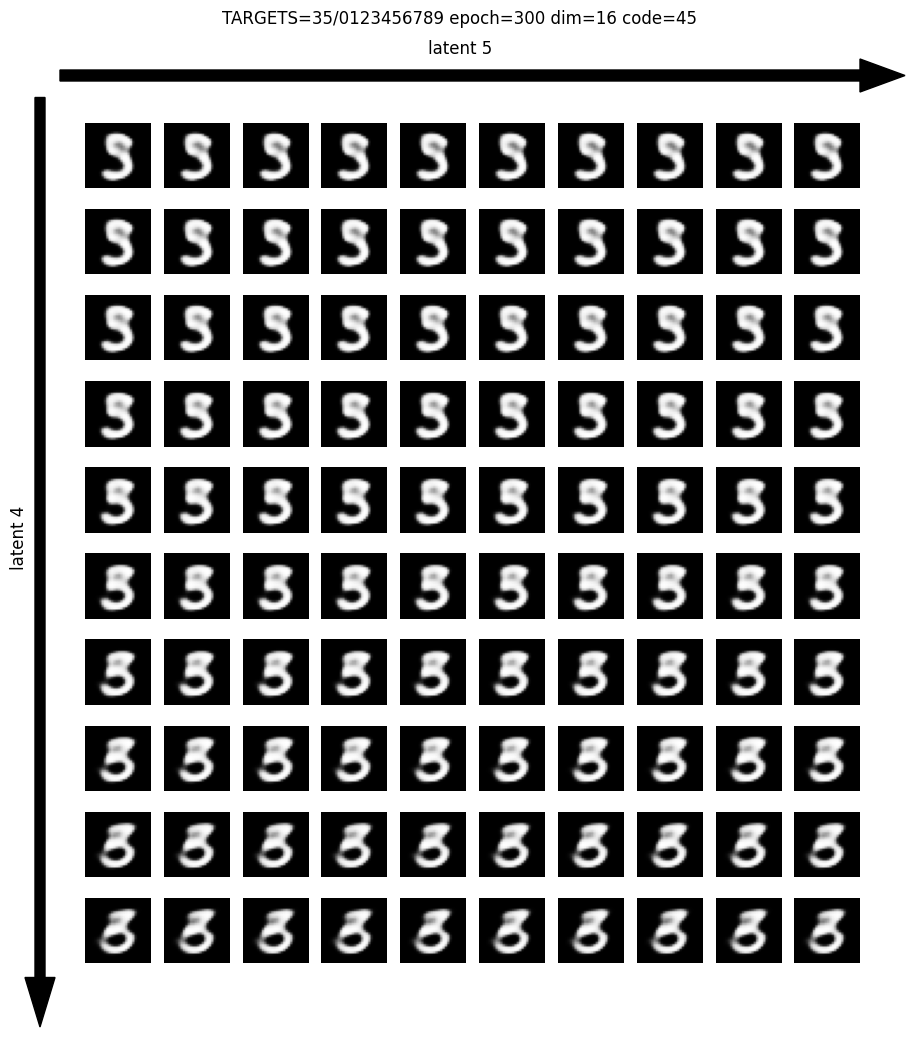

In [15]:
# generator_seed = np.random.uniform(-0.25, 0.25, (100, n_qubits)) # 원래 값 범위에서 1/4로 줄임.
mid = (SEED_L + SEED_R) / 2
generator_seed = np.random.uniform(mid, mid, (100, 2**n_qubits))

for i in range(100):
    r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
    generator_seed[i, -2] = SEED_L + (SEED_R-SEED_L) * r / 9
    generator_seed[i, -1] = SEED_L + (SEED_R-SEED_L) * r / 9
reconstructed = generate_image(generator, generator_seed)
visualize_output2(reconstructed, n_qubits-1, n_qubits)

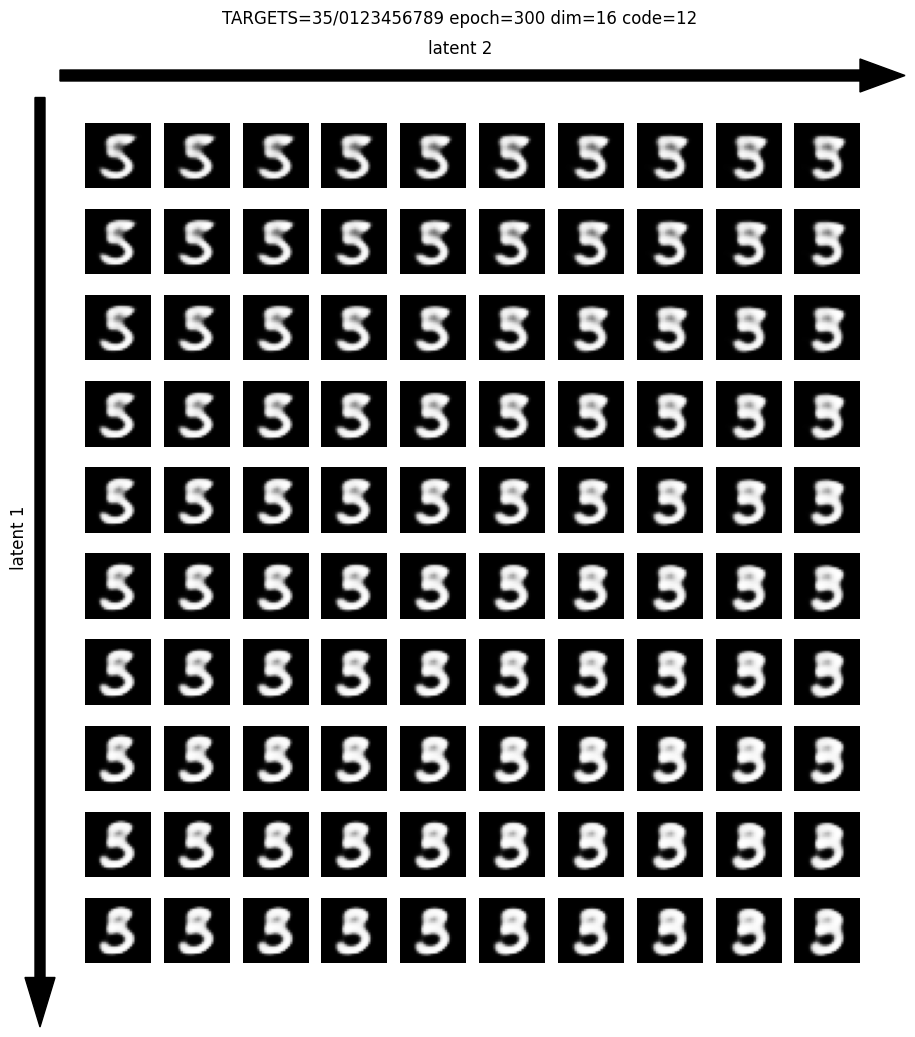

In [16]:
# generator_seed = np.random.uniform(-0.25, 0.25, (100, n_qubits)) # 원래 값 범위에서 1/4로 줄임.
mid=(SEED_L + SEED_R) / 2
generator_seed = np.random.uniform(mid,mid, (100, 2**n_qubits))

for i in range(100):
    r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
    generator_seed[i, 0] = SEED_L + (SEED_R-SEED_L) * r / 9
    generator_seed[i, 1] = SEED_L + (SEED_R-SEED_L) * c / 9
reconstructed = generate_image(generator, generator_seed)
visualize_output2(reconstructed, 1, 2)

In [19]:
base_seed = np.random.uniform(mid*0.9, mid*1.1, (100, 2**n_qubits))
from tqdm import tqdm

for t in tqdm(range(2**n_qubits)):
    generator_seed = np.zeros((100, 2**n_qubits))
    for i in range(100):
        r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
        generator_seed[i] = base_seed[r].copy()
        generator_seed[i][t] = SEED_L + (SEED_R-SEED_L) * c / 9
    reconstructed = generate_image(generator, generator_seed)
    visualize_output1(reconstructed, t+1, hide=True)

100%|██████████| 32/32 [01:11<00:00,  2.24s/it]
